<a href="https://colab.research.google.com/github/sisiradevan/portfolio/blob/main/Project_team_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
 !pip install vaderSentiment textblob wordcloud -q

import nltk
[nltk.download(x) for x in ('punkt', 'stopwords', 'averaged_perceptron_tagger')]

print("Setup complete!")

Setup complete!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

print("All imports done!")

All imports done!


In [8]:
df=pd.read_csv("/content/youtube_sentiment_dataset.csv")
df.head()

,comment_id,comment_text,video_title,channel_name,likes,reply_count,published_date,vader_compound,tb_polarity,tb_subjectivity,sentiment_label,language_detected
0,CMT00001,"This is the worst video I have ever seen, wast...",Machine Learning Crash Course,Telusko,4,0,2025-03-08 01:01:00,-0.2929,-0.7674,0.1750,Negative,English
1,CMT00002,"I cannot believe this has so many views, very ...",SQL for Data Analysis,Programming with Mosh,30,17,2024-01-07 05:44:00,-0.8031,-0.3826,0.4381,Negative,English
2,CMT00003,"Absolutely brilliant explanation, 10 out of 10...",Reinforcement Learning Guide,CampusX,65,2,2025-04-15 17:07:00,0.1461,0.4109,0.8785,Positive,English
3,CMT00004,"Not helpful at all, I had to go elsewhere to u...",Machine Learning Crash Course,TechWithTim,9,10,2024-08-21 09:05:00,-0.1577,-0.6564,0.7843,Negative,English
4,CMT00005,"This video deserves way more views, so underra...",Machine Learning Crash Course,Programming with Mosh,8,2,2024-09-07 05:29:00,0.2029,0.3875,0.4036,Positive,Hinglish


In [9]:
print("Dataset Shape:", df.shape)
print("Columns:", list(df.columns))

Dataset Shape: (2100, 12)
Columns: ['comment_id', 'comment_text', 'video_title', 'channel_name', 'likes', 'reply_count', 'published_date', 'vader_compound', 'tb_polarity', 'tb_subjectivity', 'sentiment_label', 'language_detected']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   comment_id         2100 non-null   object 
 1   comment_text       2100 non-null   object 
 2   video_title        2100 non-null   object 
 3   channel_name       2100 non-null   object 
 4   likes              2100 non-null   int64  
 5   reply_count        2100 non-null   int64  
 6   published_date     2100 non-null   object 
 7   vader_compound     2100 non-null   float64
 8   tb_polarity        2100 non-null   float64
 9   tb_subjectivity    2100 non-null   float64
 10  sentiment_label    2100 non-null   object 
 11  language_detected  2100 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 197.0+ KB


In [12]:
df.describe ()
df.head()

,comment_id,comment_text,video_title,channel_name,likes,reply_count,published_date,vader_compound,tb_polarity,tb_subjectivity,sentiment_label,language_detected
0,CMT00001,"This is the worst video I have ever seen, wast...",Machine Learning Crash Course,Telusko,4,0,2025-03-08 01:01:00,-0.2929,-0.7674,0.1750,Negative,English
1,CMT00002,"I cannot believe this has so many views, very ...",SQL for Data Analysis,Programming with Mosh,30,17,2024-01-07 05:44:00,-0.8031,-0.3826,0.4381,Negative,English
2,CMT00003,"Absolutely brilliant explanation, 10 out of 10...",Reinforcement Learning Guide,CampusX,65,2,2025-04-15 17:07:00,0.1461,0.4109,0.8785,Positive,English
3,CMT00004,"Not helpful at all, I had to go elsewhere to u...",Machine Learning Crash Course,TechWithTim,9,10,2024-08-21 09:05:00,-0.1577,-0.6564,0.7843,Negative,English
4,CMT00005,"This video deserves way more views, so underra...",Machine Learning Crash Course,Programming with Mosh,8,2,2024-09-07 05:29:00,0.2029,0.3875,0.4036,Positive,Hinglish


In [13]:
df.nunique()
df.head()

,comment_id,comment_text,video_title,channel_name,likes,reply_count,published_date,vader_compound,tb_polarity,tb_subjectivity,sentiment_label,language_detected
0,CMT00001,"This is the worst video I have ever seen, wast...",Machine Learning Crash Course,Telusko,4,0,2025-03-08 01:01:00,-0.2929,-0.7674,0.1750,Negative,English
1,CMT00002,"I cannot believe this has so many views, very ...",SQL for Data Analysis,Programming with Mosh,30,17,2024-01-07 05:44:00,-0.8031,-0.3826,0.4381,Negative,English
2,CMT00003,"Absolutely brilliant explanation, 10 out of 10...",Reinforcement Learning Guide,CampusX,65,2,2025-04-15 17:07:00,0.1461,0.4109,0.8785,Positive,English
3,CMT00004,"Not helpful at all, I had to go elsewhere to u...",Machine Learning Crash Course,TechWithTim,9,10,2024-08-21 09:05:00,-0.1577,-0.6564,0.7843,Negative,English
4,CMT00005,"This video deserves way more views, so underra...",Machine Learning Crash Course,Programming with Mosh,8,2,2024-09-07 05:29:00,0.2029,0.3875,0.4036,Positive,Hinglish


In [14]:
missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("No missing values found.")

comment_id           0
comment_text         0
video_title          0
channel_name         0
likes                0
reply_count          0
published_date       0
vader_compound       0
tb_polarity          0
tb_subjectivity      0
sentiment_label      0
language_detected    0
dtype: int64
No missing values found.


In [15]:
counts = df['sentiment_label'].value_counts()

print("Sentiment Distribution:")
print(counts)

Sentiment Distribution:
sentiment_label
Positive    1030
Negative     545
Neutral      525
Name: count, dtype: int64


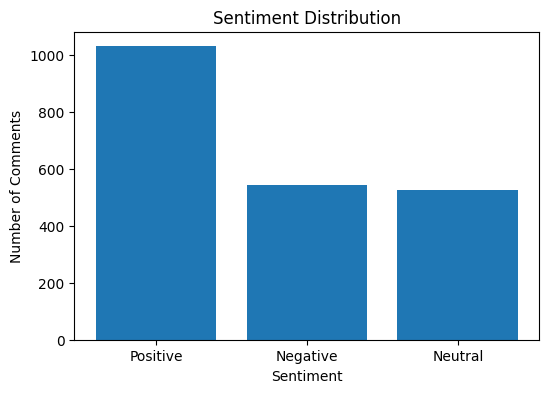

In [16]:
counts = df['sentiment_label'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

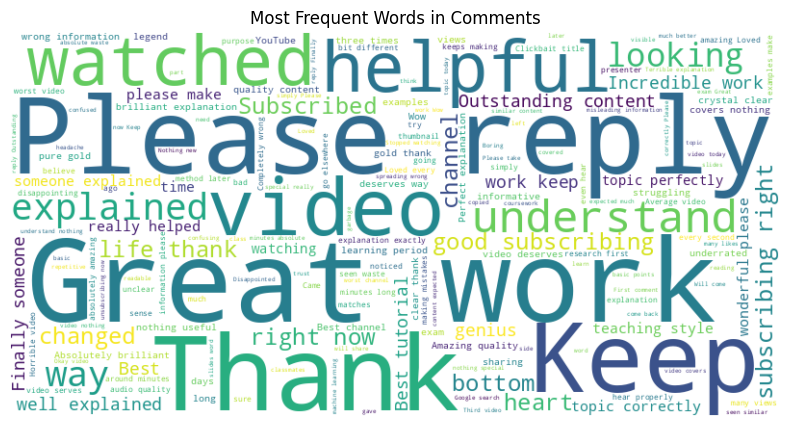

In [17]:
from wordcloud import WordCloud

text = ' '.join(df['comment_text'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Comments')
plt.show()

In [18]:
print(df['language_detected'].value_counts())

language_detected
English     1449
Hinglish     317
Hindi        229
Tamil        105
Name: count, dtype: int64


In [19]:
!pip install scikit-learn imbalanced-learn -q
print("Libraries installed!")

Libraries installed!


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.pipeline import Pipeline
import re
print("ML imports done!")

ML imports done!


In [21]:
for col in ['likes', 'reply_count']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower, upper)

print("Outliers handled.")

Outliers handled.


In [22]:
import re

def clean_text(text):
    text = str(text).lower()                  # Convert to lowercase
    text = re.sub(r'http\S+', '', text)       # Remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # Remove special characters
    return text

df['cleaned_comment'] = df['comment_text'].apply(clean_text)

print("Text cleaning completed!")
print(df[['comment_text', 'cleaned_comment']].head())

Text cleaning completed!
                                        comment_text  \
0  This is the worst video I have ever seen, wast...   
1  I cannot believe this has so many views, very ...   
2  Absolutely brilliant explanation, 10 out of 10...   
3  Not helpful at all, I had to go elsewhere to u...   
4  This video deserves way more views, so underra...   

                                     cleaned_comment  
0  this is the worst video i have ever seen waste...  
1  i cannot believe this has so many views very d...  
2  absolutely brilliant explanation 10 out of 10 ...  
3  not helpful at all i had to go elsewhere to un...  
4  this video deserves way more views so underrated   


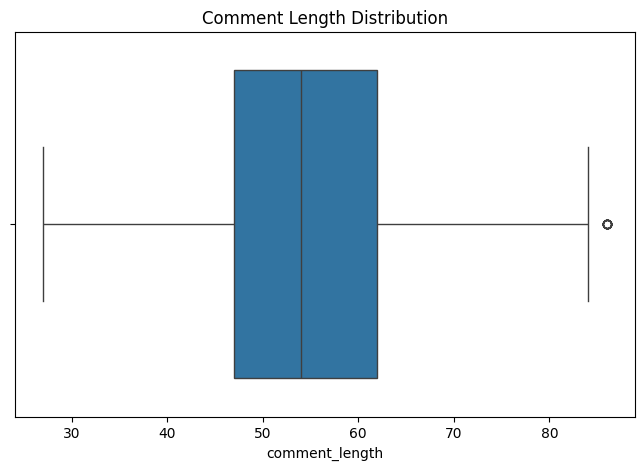

In [23]:
df["comment_length"] = df["cleaned_comment"].apply(len)

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["comment_length"]
)

plt.title("Comment Length Distribution")

plt.show()

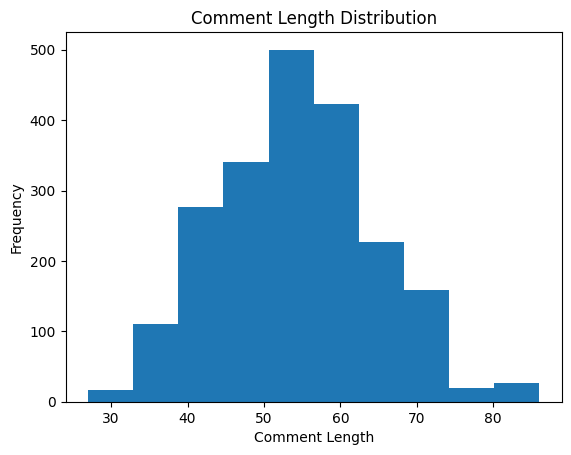

In [24]:
plt.hist(df["comment_length"])

plt.title("Comment Length Distribution")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")

plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sentiment_encoded'] = le.fit_transform(df['sentiment_label'])

print("Label Encoding Completed")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Label Encoding Completed
{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['likes', 'reply_count']] = scaler.fit_transform(
    df[['likes', 'reply_count']]
)

print("Feature scaling completed.")

Feature scaling completed.


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)


X_text = tfidf.fit_transform(df['cleaned_comment'])

print("TF-IDF Shape:", X_text.shape)

TF-IDF Shape: (2100, 805)


In [28]:
from sklearn.model_selection import train_test_split

X = X_text
y = df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (1680, 805)
Testing data : (420, 805)


In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

print("Training Models...\n")

for name, model in models.items():
    start = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred) * 100
    elapsed = time.time() - start

    print(f"{name}")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Time: {elapsed:.2f} sec\n")

Training Models...

Naive Bayes
Accuracy: 100.00%
Time: 0.01 sec

Logistic Regression
Accuracy: 100.00%
Time: 0.05 sec

Decision Tree
Accuracy: 100.00%
Time: 0.03 sec

Random Forest
Accuracy: 100.00%
Time: 0.41 sec

Gradient Boosting
Accuracy: 100.00%
Time: 2.82 sec



In [30]:
names = []
accuracy = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    names.append(name)
    accuracy.append(accuracy_score(y_test, pred) * 100)

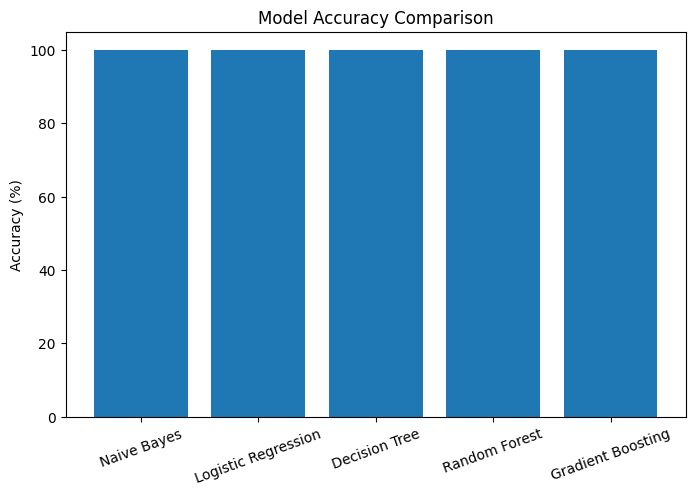

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(names, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)
plt.show()

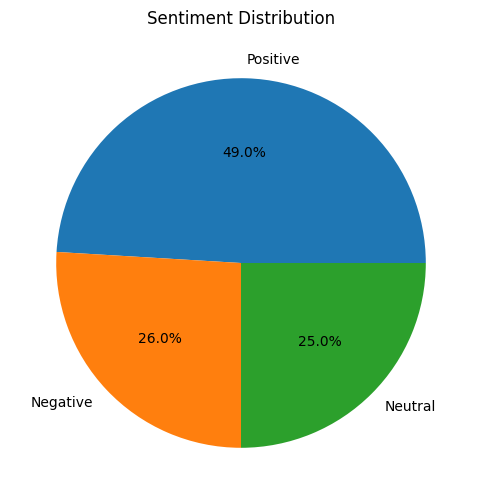

In [32]:
sentiment_counts = df['sentiment_label'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

In [33]:
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred) * 100)

print("\nClassification Report:")
print(classification_report(y_test, pred))

Accuracy: 100.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        96
           2       1.00      1.00      1.00       221

    accuracy                           1.00       420
   macro avg       1.00      1.00      1.00       420
weighted avg       1.00      1.00      1.00       420



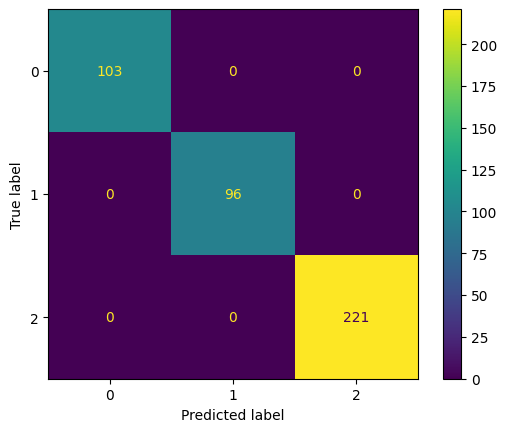

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [35]:
from sklearn.metrics import accuracy_score, f1_score

pred = model.predict(X_test)

acc = accuracy_score(y_test, pred) * 100
f1 = f1_score(y_test, pred, average='weighted') * 100

print("Accuracy:", round(acc, 2), "%")
print("F1 Score:", round(f1, 2), "%")

Accuracy: 100.0 %
F1 Score: 100.0 %


In [36]:
# Sample comments
comments = [
    "This video is amazing!",
    "Worst video ever.",
    "I watched this for my assignment."
]

for comment in comments:
    prediction = model.predict(tfidf.transform([comment]))
    sentiment = le.inverse_transform(prediction)[0]

    print("Comment:", comment)
    print("Sentiment:", sentiment)
    print("-" * 30)

Comment: This video is amazing!
Sentiment: Positive
------------------------------
Comment: Worst video ever.
Sentiment: Negative
------------------------------
Comment: I watched this for my assignment.
Sentiment: Positive
------------------------------


In [37]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
import joblib

model = joblib.load("sentiment_model.pkl")
print("Model loaded successfully!")

In [39]:
comment = input("Enter a YouTube comment: ")

pred = model.predict(tfidf.transform([comment]))
sentiment = le.inverse_transform(pred)[0]

print("Predicted Sentiment:", sentiment)

Enter a YouTube comment: good
Predicted Sentiment: Positive


In [40]:
import pickle

# Save model
pickle.dump(model, open("sentiment_model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!


In [41]:
!pip install gradio

In [42]:
import gradio as gr
import joblib

model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

def predict_sentiment(comment):
    pred = model.predict(vectorizer.transform([comment]))
    sentiment = le.inverse_transform(pred)[0]
    return sentiment

app = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Enter YouTube comment"),
    outputs="text",
    title="YouTube Comment Sentiment Analysis"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dee6f5031a98491941.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
